# Besafe Training using vecotizers

This is the script that was used to crreat the Besafe model with tensorflow vectorizer

This is a model for threat classification, and it uses NLP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.layers import TextVectorization,Embedding,LSTM,Dense,Dropout,Bidirectional
from tensorflow.keras.optimizers import Adam
import re

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/finalBesafe.csv')

In [ ]:
# len (df)
len(df)

13407

In [ ]:
df.columns

Index(['Unnamed: 0', 'Text', 'Label'], dtype='object')

In [ ]:
df['Text'].value_counts()

In [ ]:
df = df[df["Label"] != '"Label"']

In [ ]:
df['Label'].value_counts()

In [ ]:
def clean_text(text):
    # Convert to string
    text = str(text)
    # Remove URLs, mentions, special characters (keep letters and spaces)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s\u0600-\u06FF]', '', text)  # Keep English/Arabic letters
    # Convert to lowercase for English part (optional)
    # For mixed language, you might want to keep case for Arabic but lower English
    # Here we lower everything for simplicity
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text



In [ ]:
df['clean_text'] = df['Text'].apply(clean_text)

In [ ]:
df['clean_text']

In [139]:
VOCAB_SIZE =10000
MAX_LEN=100

In [ ]:
x =df['clean_text'].values
y =df_Sec['Label'].values.astype(int)

This is where we split the dataset for training and testing

In [152]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42, shuffle=True, stratify=y)

In [ ]:
Y_train_numeric = np.array(y_train)

In [ ]:
y_train_numeric = np.array(y_train)
y_test_numeric = np.array(y_test)

In [ ]:
print("Unique labels:", set(Y_train_numeric))
print("Data type:", type(Y_train_numeric[0]))

Unique labels: {np.int64(0), np.int64(1)}
Data type: <class 'numpy.int64'>


In [162]:
vectorizer = TextVectorization(
    max_tokens=200,
    output_sequence_length=MAX_LEN,
    standardize=None
)


In [163]:
vectorizer.adapt(x_test)

In [165]:
vectorizer.get_weights()

[]

In [135]:
pickle.dump({'config': vectorizer.get_config(),
             'weights': vectorizer.get_weights()},
            open('/content/drive/MyDrive/vectorizerSec.pkl', 'wb'))

In [ ]:
# np.unique(x_test,return_counts=True)
# Where every word in the sentennce is vertorised
x_train_vectorized = vectorizer(np.array([[s] for s in x_train])).numpy()
x_test_vectorized = vectorizer(np.array([[s] for s in x_test])).numpy()

Model building

In [ ]:
EMBEDDING_DIM =128
LSTM_UNITS =32
# Model parameters

model = models.Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, dropout=0.3, return_sequences=False)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.build(input_shape=(None, MAX_LEN))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,841 (5.05 MB)

 Trainable params: 1,323,841 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping and model checkpoint
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('/content/drive/MyDrive/BEsafe_models/Besafe_modelSec_feb21.h5', save_best_only=True)
]

In [ ]:


history = model.fit(
    x_train_vectorized,
    y_train_numeric,
    validation_split=0.3,  # Use part of training for validation
    epochs=60,
    shuffle=True,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/60
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5386 - loss: 0.6923 - precision_2: 0.5492 - recall_2: 0.9128

206/206 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5387 - loss: 0.6922 - precision_2: 0.5492 - recall_2: 0.9131 - val_accuracy: 0.5350 - val_loss: 0.6893 - val_precision_2: 0.5350 - val_recall_2: 1.0000
Epoch 2/60
204/206 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5713 - loss: 0.6875 - precision_2: 0.5660 - recall_2: 0.9866

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5712 - loss: 0.6875 - precision_2: 0.5658 - recall_2: 0.9867 - val_accuracy: 0.5350 - val_loss: 0.6848 - val_precision_2: 0.5350 - val_recall_2: 1.0000
Epoch 3/60
203/206 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5683 - loss: 0.6841 - precision_2: 0.5605 - recall_2: 0.9886

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5683 - loss: 0.6840 - precision_2: 0.5605 - recall_2: 0.9886 - val_accuracy: 0.5350 - val_loss: 0.6774 - val_precision_2: 0.5350 - val_recall_2: 1.0000
Epoch 4/60
204/206 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5913 - loss: 0.6760 - precision_2: 0.5764 - recall_2: 0.9904

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5913 - loss: 0.6760 - precision_2: 0.5764 - recall_2: 0.9904 - val_accuracy: 0.5744 - val_loss: 0.6662 - val_precision_2: 0.5570 - val_recall_2: 1.0000
Epoch 5/60
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6331 - loss: 0.6660 - precision_2: 0.6049 - recall_2: 0.9727

...

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9906 - loss: 0.0477 - precision_2: 0.9915 - recall_2: 0.9911 - val_accuracy: 0.9883 - val_loss: 0.0398 - val_precision_2: 0.9894 - val_recall_2: 0.9887
Epoch 55/60
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9917 - loss: 0.0422 - precision_2: 0.9910 - recall_2: 0.9940

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9917 - loss: 0.0422 - precision_2: 0.9910 - recall_2: 0.9940 - val_accuracy: 0.9883 - val_loss: 0.0393 - val_precision_2: 0.9894 - val_recall_2: 0.9887
Epoch 56/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9911 - loss: 0.0422 - precision_2: 0.9912 - recall_2: 0.9927

206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9911 - loss: 0.0422 - precision_2: 0.9912 - recall_2: 0.9927 - val_accuracy: 0.9883 - val_loss: 0.0388 - val_precision_2: 0.9894 - val_recall_2: 0.9887
Epoch 57/60
205/206 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9910 - loss: 0.0399 - precision_2: 0.9891 - recall_2: 0.9949

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9910 - loss: 0.0399 - precision_2: 0.9891 - recall_2: 0.9949 - val_accuracy: 0.9893 - val_loss: 0.0383 - val_precision_2: 0.9913 - val_recall_2: 0.9887
Epoch 58/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9934 - loss: 0.0366 - precision_2: 0.9938 - recall_2: 0.9941 - val_accuracy: 0.9890 - val_loss: 0.0386 - val_precision_2: 0.9913 - val_recall_2: 0.9880
Epoch 59/60
202/206 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0379 - precision_2: 0.9925 - recall_2: 0.9915

206/206 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9912 - loss: 0.0380 - precision_2: 0.9925 - recall_2: 0.9915 - val_accuracy: 0.9890 - val_loss: 0.0375 - val_precision_2: 0.9913 - val_recall_2: 0.9880
Epoch 60/60
206/206 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9932 - loss: 0.0325 - precision_2: 0.9928 - recall_2: 0.9948 - val_accuracy: 0.9897 - val_loss: 0.0382 - val_precision_2: 0.9927 - val_recall_2: 0.9880


In [ ]:
# Load best model
model = models.load_model('/content/drive/MyDrive/BEsafe_models/Besafe_modelSec_feb21.h5')

# Predict on test set
y_pred_prob = model.predict(x_test_vectorized)
y_pred = (y_pred_prob > 0.5).astype(int)

# Classification report
print(classification_report(y_test_numeric, y_pred, target_names=['Non-Threat', 'Threat']))

# Confusion matrix
cm = confusion_matrix(y_test_numeric, y_pred)
print(cm)

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

  Non-Threat       0.98      0.99      0.99      1825
      Threat       0.99      0.98      0.99      2197

    accuracy                           0.99      4022
   macro avg       0.99      0.99      0.99      4022
weighted avg       0.99      0.99      0.99      4022

[[1806   19]
 [  35 2162]]


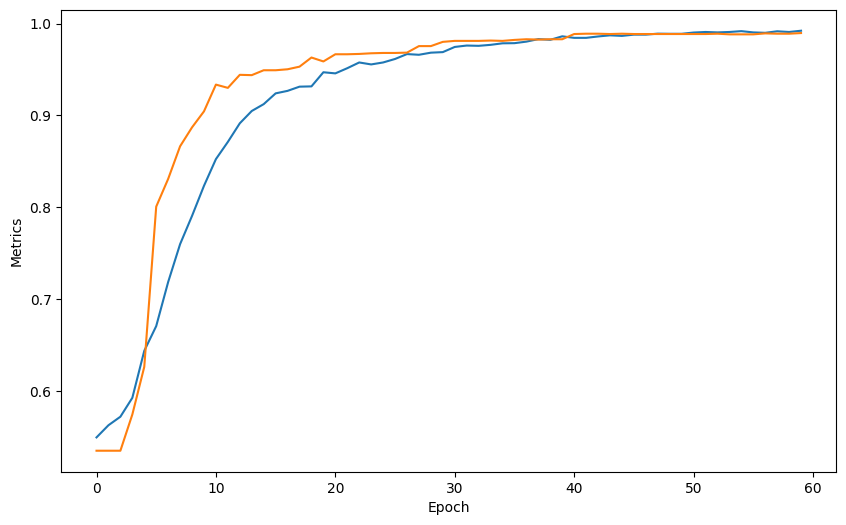

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.show()

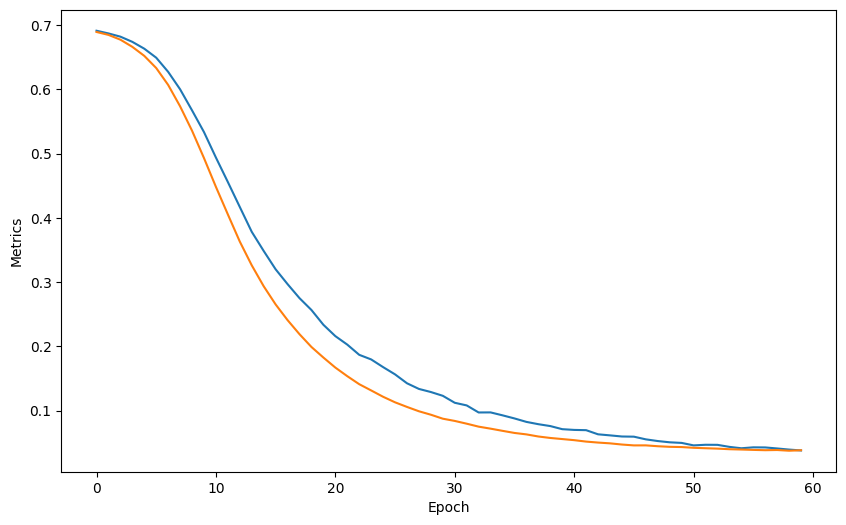

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Accuracy')
plt.plot(history.history['val_loss'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.show()

In [ ]:

label_mapping = {"threat": 1, "Non-threat": 0}

In [ ]:
def predict_threat(text, model, vectorizer, threshold=0.5):
    cleaned = clean_text(text)
    # Vectorize (needs to be in a list)
    vec = vectorizer([cleaned]).numpy()
    prob = model.predict(vec)[0][0]
    label = int(prob > threshold)
    return label, prob

In [133]:
# Example
text = 'we need urgent security intervention, we are in danger'
label, prob = predict_threat(text, model, vectorizer)
label = list(label_mapping.keys())[list(label_mapping.values()).index(label)]
print(f"Text: {text}\nPreediction: {label} (probability: {prob:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Text: we need urgent security intervention, we are in danger
Preediction: threat (probability: 0.6568)
